Step 1 — understand the sigmoid visually

sigmoid( -10) = 0.0000
sigmoid(  -5) = 0.0067
sigmoid(  -2) = 0.1192
sigmoid(  -1) = 0.2689
sigmoid(   0) = 0.5000
sigmoid(   1) = 0.7311
sigmoid(   2) = 0.8808
sigmoid(   5) = 0.9933
sigmoid(  10) = 1.0000


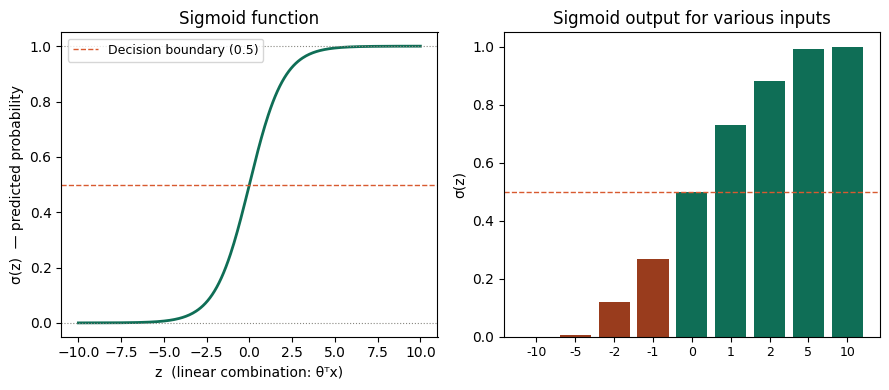

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 300)
sig = sigmoid(z)

plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(z, sig, color='#0F6E56', linewidth=2)
plt.axhline(0.5, color='#D85A30', linestyle='--', linewidth=1, label='Decision boundary (0.5)')
plt.axhline(0,   color='#888780', linestyle=':',  linewidth=0.8)
plt.axhline(1,   color='#888780', linestyle=':',  linewidth=0.8)
plt.xlabel('z  (linear combination: θᵀx)')
plt.ylabel('σ(z)  — predicted probability')
plt.title('Sigmoid function')
plt.legend(fontsize=9)

# Show how it squashes extreme values
plt.subplot(1, 2, 2)
test_vals = [-10, -5, -2, -1, 0, 1, 2, 5, 10]
for v in test_vals:
    print(f"sigmoid({v:4d}) = {sigmoid(v):.4f}")

# Why it works: as z→+∞, output→1; as z→-∞, output→0
plt.bar(range(len(test_vals)), [sigmoid(v) for v in test_vals],
        color=['#993C1D' if sigmoid(v)<0.5 else '#0F6E56' for v in test_vals])
plt.xticks(range(len(test_vals)), test_vals, fontsize=9)
plt.axhline(0.5, color='#D85A30', linestyle='--', linewidth=1)
plt.ylabel('σ(z)')
plt.title('Sigmoid output for various inputs')
plt.tight_layout()
plt.show()

Step 2 — show why MSE fails for classification

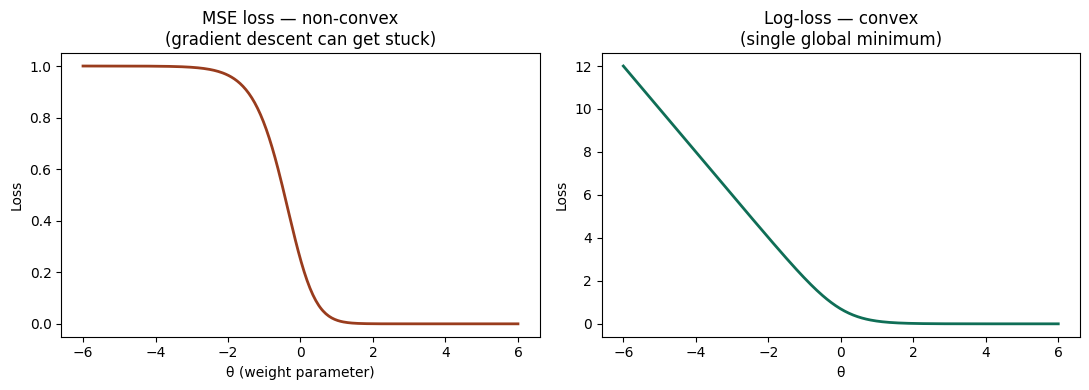

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Model: y^​=σ(θ⋅x)

theta = np.linspace(-6, 6, 300)
x_val = 2.0   # single feature value
y_true = 1    # true label is positive class

def sigmoid(z): return 1/(1+np.exp(-z))

# MSE loss: non-convex — has multiple local minima!
mse_loss = (y_true - sigmoid(theta * x_val))**2  #L=(y−y^​)2 = L=(1−σ(θx))2

# Log-loss: convex — gradient descent always finds the global minimum
logloss = -(y_true * np.log(sigmoid(theta * x_val) + 1e-15)
          + (1 - y_true) * np.log(1 - sigmoid(theta * x_val) + 1e-15))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(theta, mse_loss,  color='#993C1D', linewidth=2)
axes[0].set_title('MSE loss — non-convex\n(gradient descent can get stuck)')
axes[0].set_xlabel('θ (weight parameter)'); axes[0].set_ylabel('Loss')

axes[1].plot(theta, logloss, color='#0F6E56', linewidth=2)
axes[1].set_title('Log-loss — convex\n(single global minimum)')
axes[1].set_xlabel('θ'); axes[1].set_ylabel('Loss')
plt.tight_layout()
plt.show()

Step 3 — fit logistic regression on Titanic

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Load Titanic directly from seaborn (no Kaggle account needed)
import seaborn as sns
df = sns.load_dataset('titanic')

# Feature engineering — keep it simple for now
df = df[['survived','pclass','sex','age','sibsp','parch','fare']].dropna()
df['sex'] = (df['sex'] == 'male').astype(int)   # encode male=1, female=0

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=1000, random_state=42))
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"y-test-values: {y_test}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['Died','Survived']))

y-test-values: 315    1
483    1
736    0
722    0
400    1
      ..
103    0
437    1
73     0
252    0
657    0
Name: survived, Length: 143, dtype: int64
Accuracy: 0.7972

Classification report:
              precision    recall  f1-score   support

        Died       0.83      0.82      0.83        85
    Survived       0.75      0.76      0.75        58

    accuracy                           0.80       143
   macro avg       0.79      0.79      0.79       143
weighted avg       0.80      0.80      0.80       143




Which features matter most? Plot the logistic regression coefficients as a bar chart.

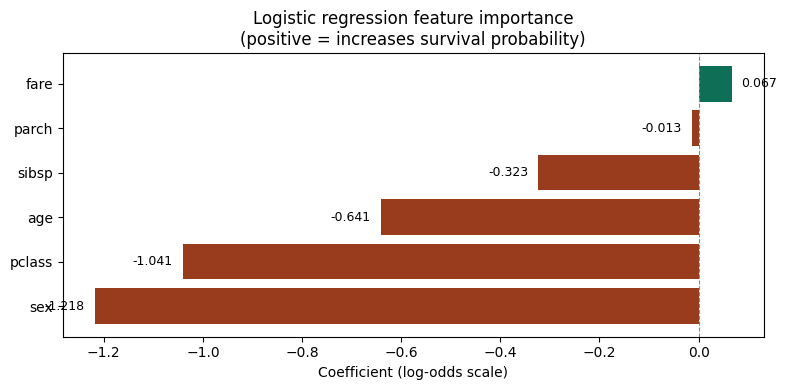


Interpretation:
  sex       : -1.218  → higher value DECREASES survival odds
  pclass    : -1.041  → higher value DECREASES survival odds
  age       : -0.641  → higher value DECREASES survival odds
  sibsp     : -0.323  → higher value DECREASES survival odds
  parch     : -0.013  → higher value DECREASES survival odds
  fare      : +0.067  → higher value INCREASES survival odds


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

feature_names = X.columns.tolist()
coefs = model.named_steps['lr'].coef_[0]  # shape: (n_features,)

coef_df = pd.Series(coefs, index=feature_names).sort_values()
colors = ['#993C1D' if c < 0 else '#0F6E56' for c in coef_df.values]

plt.figure(figsize=(8, 4))
bars = plt.barh(coef_df.index, coef_df.values, color=colors)
plt.axvline(0, color='#888780', linewidth=0.8, linestyle='--')
plt.xlabel('Coefficient (log-odds scale)')
plt.title('Logistic regression feature importance\n(positive = increases survival probability)')

for bar, val in zip(bars, coef_df.values):
    plt.text(val + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
for feat, coef in coef_df.items():
    direction = "INCREASES" if coef > 0 else "DECREASES"
    print(f"  {feat:10s}: {coef:+.3f}  → higher value {direction} survival odds")

What happens when you use class_weight='balanced'? Why does it change results?

In [ ]:
from sklearn.metrics import classification_report

# Count class imbalance
print("Class distribution in training set:")
print(y_train.value_counts())
print(f"Imbalance ratio: {y_train.value_counts()[0]/y_train.value_counts()[1]:.2f}:1\n")

# Default model
model_default = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
model_default.fit(X_train, y_train)
y_pred_default = model_default.predict(X_test)

# Balanced model
model_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42,
                              class_weight='balanced'))
])
model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_test)

print("=== Default class_weight ===")
print(classification_report(y_test, y_pred_default, target_names=['Died','Survived']))

print("=== class_weight='balanced' ===")
print(classification_report(y_test, y_pred_balanced, target_names=['Died','Survived']))

Class distribution in training set:
survived
0    339
1    232
Name: count, dtype: int64
Imbalance ratio: 1.46:1

=== Default class_weight ===
              precision    recall  f1-score   support

        Died       0.83      0.82      0.83        85
    Survived       0.75      0.76      0.75        58

    accuracy                           0.80       143
   macro avg       0.79      0.79      0.79       143
weighted avg       0.80      0.80      0.80       143

=== class_weight='balanced' ===
              precision    recall  f1-score   support

        Died       0.84      0.79      0.81        85
    Survived       0.71      0.78      0.74        58

    accuracy                           0.78       143
   macro avg       0.78      0.78      0.78       143
weighted avg       0.79      0.78      0.78       143



Step 1 — confusion matrix from scratch

Confusion matrix (scratch):
  TN=70  FP=15
  FN=14  TP=44

Sklearn confusion matrix (should match):
[[70 15]
 [14 44]]


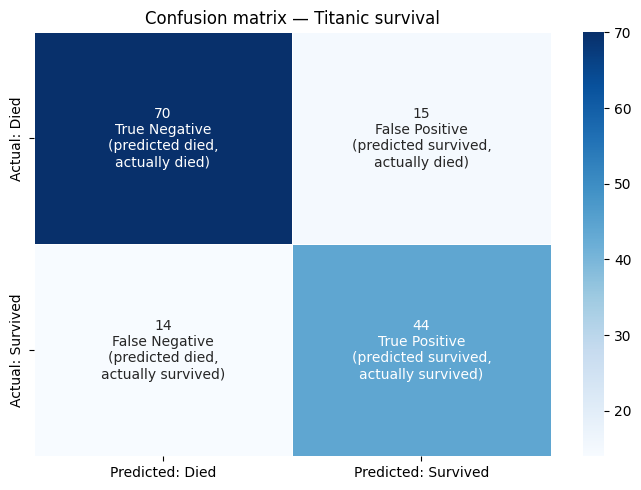

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reuse the Titanic model and predictions from Friday
# (assumes y_test and y_pred are defined)

def confusion_matrix_scratch(y_true, y_pred):
    """Returns [[TN, FP], [FN, TP]]"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))  # predicted survived, actually died
    FN = np.sum((y_true == 1) & (y_pred == 0))  # predicted died, actually survived
    return np.array([[TN, FP], [FN, TP]])

cm = confusion_matrix_scratch(y_test, y_pred)
print("Confusion matrix (scratch):")
print(f"  TN={cm[0,0]}  FP={cm[0,1]}")
print(f"  FN={cm[1,0]}  TP={cm[1,1]}")

# Verify against sklearn
from sklearn.metrics import confusion_matrix
cm_sk = confusion_matrix(y_test, y_pred)
print("\nSklearn confusion matrix (should match):")
print(cm_sk)

# Visualise
labels = [['True Negative\n(predicted died,\nactually died)',
           'False Positive\n(predicted survived,\nactually died)'],
          ['False Negative\n(predicted died,\nactually survived)',
           'True Positive\n(predicted survived,\nactually survived)']]

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=np.array([[f"{v}\n{l}" for v,l in zip(row, lrow)]
                                 for row,lrow in zip(cm, labels)]),
            fmt='', cmap='Blues', linewidths=0.5,
            xticklabels=['Predicted: Died','Predicted: Survived'],
            yticklabels=['Actual: Died','Actual: Survived'])
plt.title('Confusion matrix — Titanic survival')
plt.tight_layout()
plt.show()

Step 2 — precision, recall, F1 from scratch

In [ ]:
def precision_scratch(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    TP = np.sum((y_true==1) & (y_pred==1))
    FP = np.sum((y_true==0) & (y_pred==1))
    return TP / (TP + FP) if (TP + FP) > 0 else 0

def recall_scratch(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    TP = np.sum((y_true==1) & (y_pred==1))
    FN = np.sum((y_true==1) & (y_pred==0))
    return TP / (TP + FN) if (TP + FN) > 0 else 0

def f1_scratch(y_true, y_pred):
    p = precision_scratch(y_true, y_pred)
    r = recall_scratch(y_true, y_pred)
    return 2*p*r / (p+r) if (p+r) > 0 else 0

p = precision_scratch(y_test, y_pred)
r = recall_scratch(y_test, y_pred)
f = f1_scratch(y_test, y_pred)
print(f"Scratch — Precision: {p:.4f}  Recall: {r:.4f}  F1: {f:.4f}")

from sklearn.metrics import precision_score, recall_score, f1_score
print(f"Sklearn — Precision: {precision_score(y_test,y_pred):.4f}  "
      f"Recall: {recall_score(y_test,y_pred):.4f}  "
      f"F1: {f1_score(y_test,y_pred):.4f}")

Scratch — Precision: 0.7458  Recall: 0.7586  F1: 0.7521
Sklearn — Precision: 0.7458  Recall: 0.7586  F1: 0.7521


ROC Curve and AUC


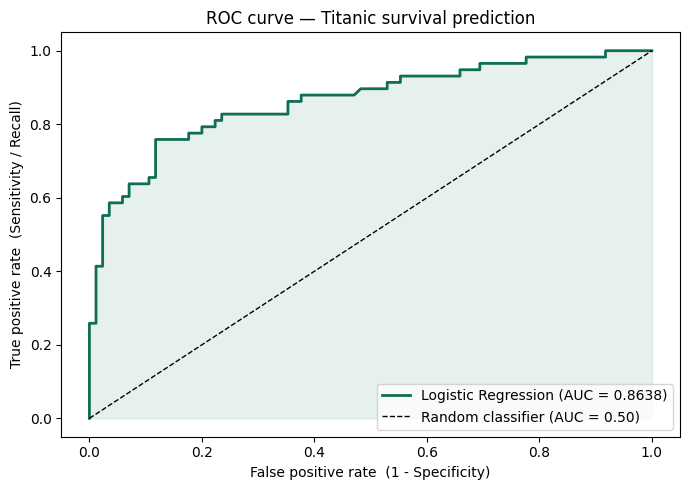


AUC: 0.8638
Optimal threshold by Youden's J: 0.5564
At this threshold — TPR: 0.7586  FPR: 0.1176


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#0F6E56', linewidth=2,
         label=f'Logistic Regression (AUC = {auc:.4f})')
plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Random classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='#0F6E56')
plt.xlabel('False positive rate  (1 - Specificity)')
plt.ylabel('True positive rate  (Sensitivity / Recall)')
plt.title('ROC curve — Titanic survival prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Find the threshold closest to the top-left corner
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"\nAUC: {auc:.4f}")
print(f"Optimal threshold by Youden's J: {optimal_threshold:.4f}")
print(f"At this threshold — TPR: {tpr[optimal_idx]:.4f}  FPR: {fpr[optimal_idx]:.4f}")


A spam filter has precision=0.95, recall=0.60. Is it good? When would you prefer high precision over high recall?

In [ ]:
import numpy as np

p, r = 0.95, 0.60
f1 = 2 * p * r / (p + r)
print(f"Precision: {p}  |  Recall: {r}  |  F1: {f1:.4f}")

# Simulate a concrete scenario: 1000 emails, 200 spam
total = 1000
spam  = 200
ham   = 800

# With recall=0.60: catches 60% of spam
tp = int(spam * r)
fn = spam - tp   # missed spam (lands in inbox)

# With precision=0.95: only 5% of flagged are actually ham
# tp / (tp + fp) = 0.95 → fp = tp*(1-0.95)/0.95
fp = int(tp * (1-p) / p)
tn = ham - fp

print(f"\nOut of {spam} spam emails:")
print(f"  Caught (TP):    {tp}  — sent to spam folder")
print(f"  Missed (FN):    {fn}  — lands in inbox (annoys the user)")
print(f"\nOut of {ham} legitimate emails:")
print(f"  Wrongly flagged (FP): {fp}  — important email goes to spam (DANGEROUS)")
print(f"  Correctly kept  (TN): {tn}")

print("\n--- When each matters more ---")
print("HIGH PRECISION preferred when false positives are costly:")
print("  Spam filter, fraud detection, legal document search")
print("  → Missing a few real events is OK; false alarms are very costly")
print("\nHIGH RECALL preferred when false negatives are costly:")
print("  Cancer screening, fraud on financial transactions, security alerts")
print("  → A missed event is far worse than investigating a false alarm")

Precision: 0.95  |  Recall: 0.6  |  F1: 0.7355

Out of 200 spam emails:
  Caught (TP):    120  — sent to spam folder
  Missed (FN):    80  — lands in inbox (annoys the user)

Out of 800 legitimate emails:
  Wrongly flagged (FP): 6  — important email goes to spam (DANGEROUS)
  Correctly kept  (TN): 794

--- When each matters more ---
HIGH PRECISION preferred when false positives are costly:
  Spam filter, fraud detection, legal document search
  → Missing a few real events is OK; false alarms are very costly

HIGH RECALL preferred when false negatives are costly:
  Cancer screening, fraud on financial transactions, security alerts
  → A missed event is far worse than investigating a false alarm


Compute F1 score manually for the Titanic model and verify it matches sklearn exactly.

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

y_true = np.array(y_test)
y_pred_arr = np.array(y_pred)

# Step 1: build counts
TP = int(np.sum((y_true==1) & (y_pred_arr==1)))
TN = int(np.sum((y_true==0) & (y_pred_arr==0)))
FP = int(np.sum((y_true==0) & (y_pred_arr==1)))
FN = int(np.sum((y_true==1) & (y_pred_arr==0)))

print(f"TP={TP}  TN={TN}  FP={FP}  FN={FN}")

# Step 2: precision and recall
precision = TP / (TP + FP)
recall    = TP / (TP + FN)

# Step 3: F1 — harmonic mean of precision and recall
f1_manual = 2 * precision * recall / (precision + recall)

# Step 4: verify
f1_sk = f1_score(y_test, y_pred)

print(f"\nManual   — P={precision:.4f}  R={recall:.4f}  F1={f1_manual:.4f}")
print(f"Sklearn  —                    F1={f1_sk:.4f}")
print(f"Match: {abs(f1_manual - f1_sk) < 1e-9}")

# Bonus: why is F1 the harmonic mean, not the arithmetic mean?
arith_mean = (precision + recall) / 2
print(f"\nArithmetic mean: {arith_mean:.4f}")
print(f"Harmonic mean:   {f1_manual:.4f}")
print(f"Harmonic is lower — it punishes imbalance between P and R more severely")

TP=44  TN=70  FP=15  FN=14

Manual   — P=0.7458  R=0.7586  F1=0.7521
Sklearn  —                    F1=0.7521
Match: True

Arithmetic mean: 0.7522
Harmonic mean:   0.7521
Harmonic is lower — it punishes imbalance between P and R more severely


Plot ROC curves for LogisticRegression, DummyClassifier, and a random classifier on the same axes.

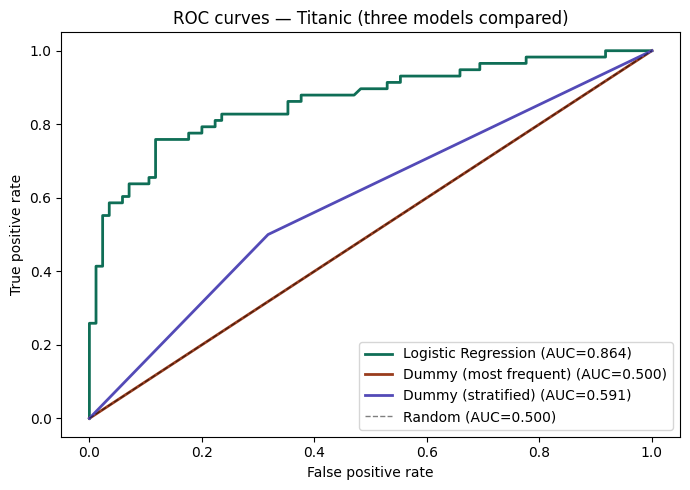

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_curve, roc_auc_score

# Build all three models
models = {
    'Logistic Regression': model,
    'Dummy (most frequent)': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', DummyClassifier(strategy='most_frequent'))
    ]),
    'Dummy (stratified)': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', DummyClassifier(strategy='stratified', random_state=42))
    ])
}

plt.figure(figsize=(7, 5))
colors = ['#0F6E56', '#993C1D', '#534AB7']

for (name, m), col in zip(models.items(), colors):
    m.fit(X_train, y_train)
    # DummyClassifier also has predict_proba
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=col, linewidth=2, label=f'{name} (AUC={auc:.3f})')

# Perfect and random reference lines
plt.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.500)')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curves — Titanic (three models compared)')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


What does AUC=0.5 mean? AUC=1.0? What is a "good" AUC for a real project?

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

np.random.seed(42)
n = 500
y_true = np.random.randint(0, 2, n)

# AUC = 0.50: random noise predictions
proba_random = np.random.uniform(0, 1, n)
auc_random = roc_auc_score(y_true, proba_random)

# AUC = 1.00: perfect predictions
proba_perfect = y_true + np.random.uniform(0, 0.01, n)  # tiny noise
auc_perfect = roc_auc_score(y_true, proba_perfect)

# AUC below 0.5: inverted model (predicts wrong class)
proba_inverted = 1 - y_true.astype(float) + np.random.uniform(0, 0.1, n)
auc_inverted = roc_auc_score(y_true, proba_inverted)

print(f"Random predictions:  AUC = {auc_random:.4f}  → no better than a coin flip")
print(f"Perfect predictions: AUC = {auc_perfect:.4f}  → model is always right")
print(f"Inverted model:      AUC = {auc_inverted:.4f}  → flip predictions to get good model")

print("\n--- Industry AUC benchmarks ---")
benchmarks = [
    ("0.50 – 0.60", "Barely better than random. Model hasn't learned anything useful."),
    ("0.60 – 0.70", "Weak. Usable only as a baseline, not for deployment."),
    ("0.70 – 0.80", "Fair. Acceptable for low-stakes applications."),
    ("0.80 – 0.90", "Good. Typical for well-tuned models on real tabular data."),
    ("0.90 – 0.95", "Very good. Common in domains with rich features."),
    ("0.95 – 1.00", "Excellent — but check for data leakage, it may be too good."),
]
for auc_range, meaning in benchmarks:
    print(f"  {auc_range}: {meaning}")

Random predictions:  AUC = 0.4839  → no better than a coin flip
Perfect predictions: AUC = 1.0000  → model is always right
Inverted model:      AUC = 0.0000  → flip predictions to get good model

--- Industry AUC benchmarks ---
  0.50 – 0.60: Barely better than random. Model hasn't learned anything useful.
  0.60 – 0.70: Weak. Usable only as a baseline, not for deployment.
  0.70 – 0.80: Fair. Acceptable for low-stakes applications.
  0.80 – 0.90: Good. Typical for well-tuned models on real tabular data.
  0.90 – 0.95: Very good. Common in domains with rich features.
  0.95 – 1.00: Excellent — but check for data leakage, it may be too good.
